## 🧩 1. Import Libraries


In [32]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")


## 📂 2. Load Dataset


In [54]:
train_path = "../data/raw/train.csv"
test_path = "../data/raw/test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

train_df.head()

Train shape: (1200, 13)
Test shape: (120, 11)


,id,journal_text,ambience_type,duration_min,sleep_hours,energy_level,stress_level,time_of_day,previous_day_mood,face_emotion_hint,reflection_quality,emotional_state,intensity
0,1,The ocean ambience helped me stop drifting and...,ocean,12,6.5,4,2,afternoon,mixed,calm_face,clear,focused,3
1,2,"I tried to relax during the forest ambience, y...",forest,35,6.0,2,4,evening,calm,tired_face,vague,restless,3
2,3,The forest session slowed my thoughts and I fe...,forest,3,NaN,2,1,night,overwhelmed,happy_face,clear,calm,3
3,4,"the mountain ambience was pleasant, though i c...",mountain,25,7.0,4,4,night,focused,calm_face,vague,neutral,1
4,5,"The rain session gave me a pause, but the pres...",rain,25,5.0,3,5,afternoon,NaN,tense_face,clear,overwhelmed,5


In [55]:
test_df.columns

Index(['id', 'journal_text', 'ambience_type', 'duration_min', 'sleep_hours',
       'energy_level', 'stress_level', 'time_of_day', 'previous_day_mood',
       'face_emotion_hint', 'reflection_quality'],
      dtype='object')

## 🔍 3. Basic Info


In [34]:
train_df.info()
train_df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  1200 non-null   int64  
 1   journal_text        1200 non-null   object 
 2   ambience_type       1200 non-null   object 
 3   duration_min        1200 non-null   int64  
 4   sleep_hours         1193 non-null   float64
 5   energy_level        1200 non-null   int64  
 6   stress_level        1200 non-null   int64  
 7   time_of_day         1200 non-null   object 
 8   previous_day_mood   1185 non-null   object 
 9   face_emotion_hint   1077 non-null   object 
 10  reflection_quality  1200 non-null   object 
 11  emotional_state     1200 non-null   object 
 12  intensity           1200 non-null   int64  
dtypes: float64(1), int64(5), object(7)
memory usage: 122.0+ KB


,id,journal_text,ambience_type,duration_min,sleep_hours,energy_level,stress_level,time_of_day,previous_day_mood,face_emotion_hint,reflection_quality,emotional_state,intensity
count,1200.000000,1200,1200,1200.000000,1193.000000,1200.000000,1200.000000,1200,1185,1077,1200,1200,1200.000000
unique,NaN,979,5,NaN,NaN,NaN,NaN,5,6,6,3,6,NaN
top,NaN,it was fine,ocean,NaN,NaN,NaN,NaN,afternoon,mixed,neutral_face,clear,calm,NaN
freq,NaN,12,268,NaN,NaN,NaN,NaN,319,213,214,411,216,NaN
mean,564.500000,NaN,NaN,15.861667,5.989522,3.016667,3.026667,NaN,NaN,NaN,NaN,NaN,3.045833
std,304.731523,NaN,NaN,7.671369,1.500732,1.381296,1.401520,NaN,NaN,NaN,NaN,NaN,1.391766
min,1.000000,NaN,NaN,3.000000,3.500000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,1.000000
25%,300.750000,NaN,NaN,10.000000,5.000000,2.000000,2.000000,NaN,NaN,NaN,NaN,NaN,2.000000
50%,600.500000,NaN,NaN,15.000000,6.000000,3.000000,3.000000,NaN,NaN,NaN,NaN,NaN,3.000000
75%,810.250000,NaN,NaN,20.000000,7.000000,4.000000,4.000000,NaN,NaN,NaN,NaN,NaN,4.000000


## ❗ 4. Missing Values Analysis


In [56]:
missing = train_df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]

missing

face_emotion_hint    123
previous_day_mood     15
sleep_hours            7
dtype: int64

## Visualization


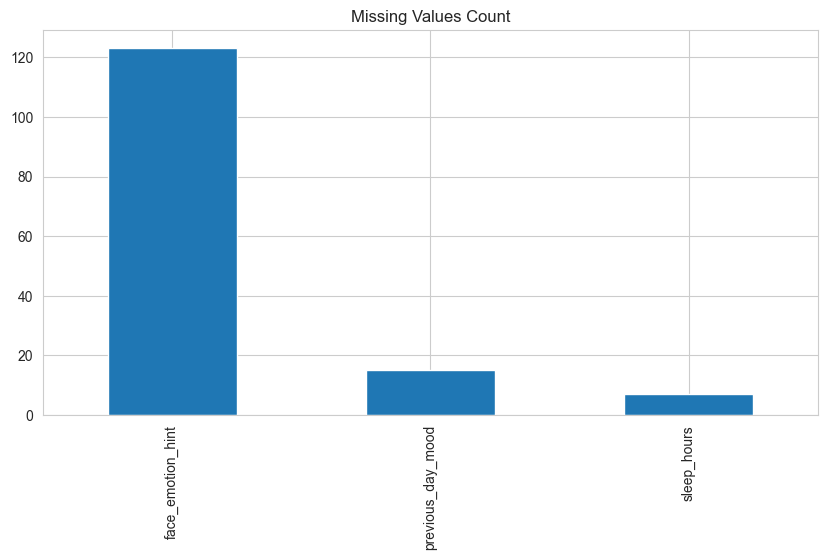

In [57]:
plt.figure(figsize=(10,5))
missing.plot(kind='bar')
plt.title("Missing Values Count")
plt.show()

## Drop columns with missing values


In [58]:
train_df.dropna(inplace=True)

## Shape of train Data set after Droping NA's


In [59]:
train_df.shape

(1056, 13)

## 🎯 5. Target Variable Analysis


- ### Emotional State Distribution


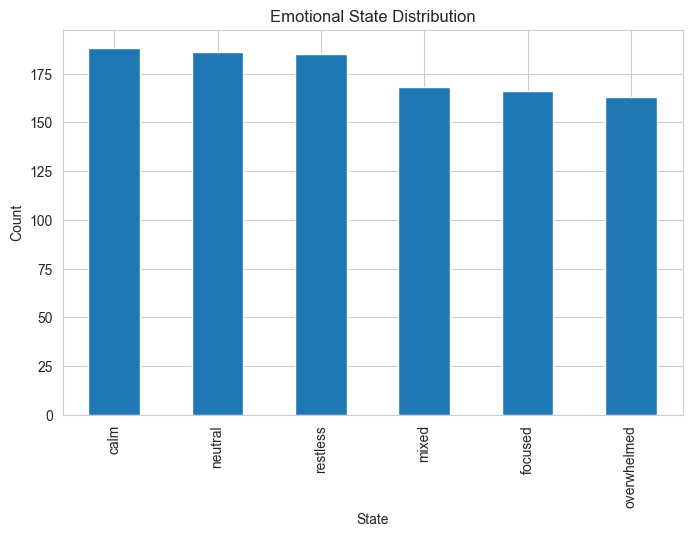

In [60]:
plt.figure(figsize=(8,5))
train_df['emotional_state'].value_counts().plot(kind='bar')
plt.title("Emotional State Distribution")
plt.xlabel("State")
plt.ylabel("Count")
plt.show()

## 🧠 Key Insights

**1. ✅ Well-balanced dataset (Very Good 👍)**

- All classes are in a tight range (163 → 188)

- No class is dominating heavily

**👉 This means:**

- No serious class imbalance problem

- Your model won’t be biased toward one emotion

- You can skip heavy techniques like SMOTE / class weighting (initially)


- ### Intensity Distribution


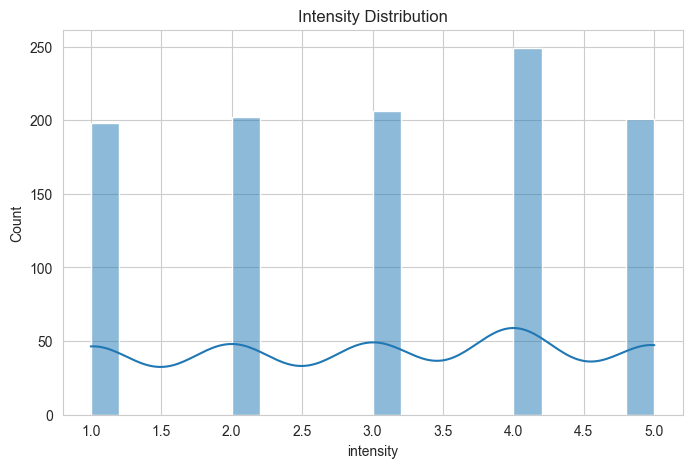

In [61]:
plt.figure(figsize=(8,5))
sns.histplot(train_df['intensity'], bins=20, kde=True)
plt.title("Intensity Distribution")
plt.show()

## 🧠 Insight

- The data is almost evenly distributed across all intensity levels (1–5).

- There is no strong imbalance (good for ML training).

- Slight peak at intensity = 4, but not dominant.

## ⚖️ Conclusion

- ✅ Dataset is balanced → good for classification models

- ⚠️ No class dominates → model must learn subtle differences

- 💡 You likely don’t need heavy resampling (like SMOTE or oversampling)


### Type of Columns


In [62]:
numerical_columns =["duration_min", "sleep_hours", "energy_level", "stress_level"]
categorical_columns = ["ambience_type", "time_of_day", "previous_day_mood", "face_emotion_hint", "reflection_quality"]
textual_columns = ["journal_text"]
target_columns=["emotional_state", "intensity"]

In [ ]:
def intensity_impact_report(df, numerical_columns, categorical_columns, target='intensity'):
    """
    Analyze the impact of each feature on 'intensity'.
    Prints trends for numerical columns (increase/decrease)
    and average intensity for each category in categorical columns.
    """
    print("🔍 Intensity Impact Analysis\n")

    # -----------------------------
    # 1️⃣ Numerical Columns
    # -----------------------------
    print("📊 Numerical Features:")
    for col in numerical_columns:
        corr = df[col].corr(df[target])
        if corr > 0.2:
            trend = "⬆️ As " + col + " increases, intensity increases"
        elif corr < -0.2:
            trend = "⬇️ As " + col + " increases, intensity decreases"
        else:
            trend = "⚖️ No strong trend with intensity"
        print(f"{col}: correlation={corr:.2f} → {trend}")

    # -----------------------------
    # 2️⃣ Categorical Columns
    # -----------------------------
    print("\n📌 Categorical Features:")
    for col in categorical_columns:
        print(f"\n➡️ {col}:")
        mean_intensity = df.groupby(col)[target].mean().sort_values()
        for cat, val in mean_intensity.items():
            print(f"   {cat}: avg intensity = {val:.2f}")

        if len(mean_intensity) > 1:
            diff = mean_intensity.max() - mean_intensity.min()
            if diff > 0.5:
                print("   👉 Some categories have higher intensity than others")
            else:
                print("   👉 No strong variation in intensity across categories")

In [66]:
intensity_impact_report(train_df, numerical_columns, categorical_columns)

🔍 Intensity Impact Analysis

📊 Numerical Features:
duration_min: correlation=-0.02 → ⚖️ No strong trend with intensity
sleep_hours: correlation=-0.03 → ⚖️ No strong trend with intensity
energy_level: correlation=0.01 → ⚖️ No strong trend with intensity
stress_level: correlation=-0.02 → ⚖️ No strong trend with intensity

📌 Categorical Features:

➡️ ambience_type:
   rain: avg intensity = 2.95
   forest: avg intensity = 2.96
   mountain: avg intensity = 3.00
   ocean: avg intensity = 3.06
   cafe: avg intensity = 3.28
   👉 No strong variation in intensity across categories

➡️ time_of_day:
   evening: avg intensity = 2.84
   night: avg intensity = 3.01
   morning: avg intensity = 3.11
   afternoon: avg intensity = 3.19
   early_morning: avg intensity = 3.39
   👉 Some categories have higher intensity than others

➡️ previous_day_mood:
   mixed: avg intensity = 2.93
   calm: avg intensity = 3.00
   restless: avg intensity = 3.03
   neutral: avg intensity = 3.08
   focused: avg intensity = 

## 🧠 3. Key Takeaways

- Numerical columns: barely correlated → intensity is likely non-linear or depends on interactions.

- Categorical columns: small variations exist, most features alone don’t strongly influence intensity.

- Time of day shows slight effect: early morning → higher intensity.

- Overall intensity is fairly stable (~3) across features → small differences might need text features to predict better.


In [68]:
from scipy.stats import chi2_contingency

def emotional_state_report(df, numerical_columns, categorical_columns, target='emotional_state'):
    """
    Generates a report showing:
    1️⃣ How numerical features vary across emotional states.
    2️⃣ How categorical features relate to emotional states.
    """
    print(f"🔍 Report for '{target}'\n")

    # -----------------------------
    # 1️⃣ Numerical Features
    # -----------------------------
    print("📊 Numerical Features vs Emotional State:")
    for col in numerical_columns:
        print(f"\n➡️ {col}:")
        mean_values = df.groupby(target)[col].mean().sort_values()
        for state, val in mean_values.items():
            print(f"   {state}: avg {col} = {val:.2f}")

        diff = mean_values.max() - mean_values.min()
        if diff > 0.5:
            print("   👉 Noticeable difference across emotional states")
        else:
            print("   👉 No strong difference across emotional states")

    # -----------------------------
    # 2️⃣ Categorical Features
    # -----------------------------
    print("\n📌 Categorical Features vs Emotional State:")
    for col in categorical_columns:
        print(f"\n➡️ {col}:")
        contingency = pd.crosstab(df[col], df[target])
        print(contingency)

        # Chi-square test for significance
        chi2, p, dof, expected = chi2_contingency(contingency)
        print(f"   chi2={chi2:.2f}, p-value={p:.3f}")
        if p < 0.05:
            print("   👉 Significant relationship with emotional_state")
        else:
            print("   👉 No significant relationship")

In [69]:
emotional_state_report(train_df, numerical_columns, categorical_columns)

🔍 Report for 'emotional_state'

📊 Numerical Features vs Emotional State:

➡️ duration_min:
   mixed: avg duration_min = 15.20
   calm: avg duration_min = 15.72
   overwhelmed: avg duration_min = 15.83
   restless: avg duration_min = 15.84
   focused: avg duration_min = 15.99
   neutral: avg duration_min = 16.12
   👉 Noticeable difference across emotional states

➡️ sleep_hours:
   overwhelmed: avg sleep_hours = 5.81
   restless: avg sleep_hours = 5.84
   mixed: avg sleep_hours = 5.98
   focused: avg sleep_hours = 6.09
   neutral: avg sleep_hours = 6.10
   calm: avg sleep_hours = 6.12
   👉 No strong difference across emotional states

➡️ energy_level:
   neutral: avg energy_level = 2.89
   overwhelmed: avg energy_level = 2.93
   restless: avg energy_level = 2.96
   mixed: avg energy_level = 3.01
   calm: avg energy_level = 3.04
   focused: avg energy_level = 3.28
   👉 No strong difference across emotional states

➡️ stress_level:
   focused: avg stress_level = 2.86
   calm: avg stress_l

## 1️⃣ Numerical Features vs Emotional State

- `duration_min`: Emotional states like neutral and focused are associated with slightly longer durations, while mixed and calm have shorter durations.
- **Interpretation**: People reporting neutral or focused states tend to spend a bit more time journaling. The difference is noticeable but not huge (~1 minute range).

- `sleep_hours`: Sleep varies minimally across emotional states (5.8–6.1 hours).
- **Interpretation**: Sleep duration doesn’t strongly differentiate emotional states in your dataset.

- `energy_level`: Focused has the highest energy, neutral the lowest. Others are in between.
- `Interpretation`: Higher energy slightly correlates with more focused states, but overall variation is small.

- `stress_level`: Neutral and overwhelmed states have slightly higher stress; focused and calm are lower.
- **Interpretation**: Stress is mildly higher in more neutral or overwhelmed moods, but overall differences are subtle.

**✅ Takeaway: Numerical features show minor trends; only duration_min shows a small noticeable variation across emotional states. Other features (sleep, energy, stress) are relatively uniform.**

## 2️⃣ Categorical Features vs Emotional State

- All chi-square p-values > 0.05, which means no statistically significant relationship between these categorical features and emotional state:

- `ambience_type`: Choice of environment (cafe, forest, ocean, etc.) doesn’t significantly affect emotional state.

- `time_of_day`: Time of day of journaling has no strong impact.

- `previous_day_mood`: Yesterday’s mood shows slight patterns but not statistically significant.

- `face_emotion_hint`: Facial expression hints (happy, calm, tense) are not significantly associated with emotional state.

- `reflection_quality`: How clearly someone reflects doesn’t significantly impact their reported emotional state.

**✅ Takeaway: Emotional state in your dataset is largely independent of categorical features. There are some minor patterns, but they are not statistically significant.**

## Overall Interpretation

- Emotional state appears mostly independent of your categorical features, suggesting factors outside the recorded categorical variables might influence it more.

- Duration of journaling shows a small trend with emotional state—longer sessions slightly correlate with focused or neutral.

- Sleep, energy, and stress levels have minor variations, but no strong signal exists to predict emotional state based solely on them.



## 6. `journel_text` impact on target variable

In [70]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import chi2

def text_impact_report(df, text_column='journal_text', intensity_col='intensity', emotion_col='emotional_state', top_n=10):
    """
    Analyze the impact of textual data on intensity (numerical) and emotional_state (categorical).

    Prints:
    1. Words positively/negatively associated with intensity
    2. Words strongly associated with emotional_state
    """
    print("🔍 Text Impact Analysis\n")

    # -----------------------------
    # 1️⃣ Convert text to TF-IDF
    # -----------------------------
    tfidf = TfidfVectorizer(max_features=500)
    X_text = tfidf.fit_transform(df[text_column])
    feature_names = tfidf.get_feature_names_out()
    X_df = pd.DataFrame(X_text.toarray(), columns=feature_names)

    # -----------------------------
    # 2️⃣ Impact on intensity
    # -----------------------------
    print("📊 Impact on Intensity:")
    model = LinearRegression()
    model.fit(X_df, df[intensity_col])

    coef = pd.Series(model.coef_, index=X_df.columns).sort_values(ascending=False)
    print(f"\nTop {top_n} words increasing intensity:")
    print(coef.head(top_n))

    print(f"\nTop {top_n} words decreasing intensity:")
    print(coef.tail(top_n))

    # -----------------------------
    # 3️⃣ Impact on emotional_state
    # -----------------------------
    print("\n📌 Impact on Emotional State:")
    # Using chi-square test for word association
    chi_scores, p_values = chi2(X_df, df[emotion_col])
    chi_df = pd.DataFrame({"word": feature_names, "chi2": chi_scores, "p_value": p_values})
    chi_df.sort_values("chi2", ascending=False, inplace=True)

    print(f"\nTop {top_n} words strongly associated with emotional states:")
    print(chi_df.head(top_n))

In [71]:
text_impact_report(
    train_df,
    text_column='journal_text',
    intensity_col='intensity',
    emotion_col='emotional_state',
    top_n=10
)

🔍 Text Impact Analysis

📊 Impact on Intensity:

Top 10 words increasing intensity:
head         11.319374
exhausted     6.111393
thought       6.048995
time          5.929041
while         5.267269
observed      5.230803
slowed        4.912003
yesterday     4.551410
rain          4.506376
mountain      4.002344
dtype: float64

Top 10 words decreasing intensity:
just        -5.528471
down        -5.710999
carrying    -5.730991
earlier     -5.812778
jumpy       -6.055315
overall     -6.643889
blank       -7.487828
mostly      -7.928684
softened    -8.085873
itchy      -13.758698
dtype: float64

📌 Impact on Emotional State:

Top 10 words strongly associated with emotional states:
            word       chi2       p_value
79       drained  42.399802  4.888955e-08
220    organized  41.895607  6.183980e-08
204      nothing  40.946319  9.620008e-08
48        calmer  36.968576  6.076988e-07
308        tasks  36.178506  8.748305e-07
137        ideas  35.776620  1.052708e-06
247        quiet  33

## 1️⃣ Impact on Intensity (Numerical)

**Top words increasing intensity:**
head, exhausted, thought, time, while, observed, slowed, yesterday, rain, mountain

- These words are associated with higher emotional intensity.

- `Interpretation`: Mentions of physical or mental strain (head, exhausted), reflection (thought, observed), time-related awareness (time, yesterday), or environment (rain, mountain) signal stronger intensity in your journaling data.

- Likely, when users are more reflective or aware of fatigue/stress, their intensity scores are higher.

**Top words decreasing intensity:**
- `just`, `down`, `carrying`, `earlier`, `jumpy`, `overall`, `blank`, `mostly`, `softened`, `itchy`

- These words are linked to lower emotional intensity.

- `Interpretation`: Words like just, overall, or mostly indicate a neutral or subdued tone, while physical states like itchy or being down may reflect less intense engagement or emotion.

**✅ Takeaway: High-intensity entries often involve stronger feelings, reflection, or noticeable environmental/physical cues, while low-intensity entries are more neutral, mundane, or mild in tone.**

### 2️⃣ Impact on Emotional State (Categorical)

- Top words strongly associated with emotional states:
- `drained`, `organized`, `nothing`, `calmer`, `tasks`, `ideas`, `quiet`, `planning`, `concentrate`, `jumping`

- These words have a strong statistical relationship with specific emotional states (chi2 very high, p-value ≪ 0.05).

## Interpretation:

- `drained`, `nothing` → likely associated with overwhelmed or restless moods.

- `calmer`, `quiet` → likely linked to calm emotional state.

- `organized`, `tasks`, `planning`, `concentrate` → may indicate focused state.

- `jumping` → could signal restless or energetic states.

## ✅ Takeaway: Certain words serve as keywords for predicting emotional states. Users’ choice of words directly signals their mood: structured/organized words → focused; calm/quiet words → calm; fatigue or negative words → overwhelmed/restless.

- Overall Insights from Text

- Textual cues are strong predictors for both intensity and emotional state.

- Intensity is triggered by words describing mental load, physical sensations, and attention to time/environment.

- Emotional state is reflected by specific keywords indicating mood, energy, and task orientation.

- For modeling purposes, including journal_text as TF-IDF or embeddings is likely much more informative than numerical/categorical metadata alone.

In [72]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import pandas as pd

def text_visual_report(df, text_column='journal_text', intensity_col='intensity', emotion_col='emotional_state', intensity_split=0.5):
    """
    Creates word clouds for textual impact:
    1. High vs Low intensity
    2. Each emotional state
    """
    print("🔍 Generating Word Clouds...\n")

    # -----------------------------
    # 1️⃣ Word clouds for intensity
    # -----------------------------
    median_intensity = df[intensity_col].median()

    high_intensity_text = " ".join(df[df[intensity_col] > median_intensity][text_column])
    low_intensity_text  = " ".join(df[df[intensity_col] <= median_intensity][text_column])

    plt.figure(figsize=(14,6))

    plt.subplot(1,2,1)
    wc_high = WordCloud(width=600, height=400, background_color='white').generate(high_intensity_text)
    plt.imshow(wc_high, interpolation='bilinear')
    plt.axis('off')
    plt.title('High Intensity Words', fontsize=16)

    plt.subplot(1,2,2)
    wc_low = WordCloud(width=600, height=400, background_color='white').generate(low_intensity_text)
    plt.imshow(wc_low, interpolation='bilinear')
    plt.axis('off')
    plt.title('Low Intensity Words', fontsize=16)

    plt.show()

    # -----------------------------
    # 2️⃣ Word clouds for each emotional state
    # -----------------------------
    emotional_states = df[emotion_col].unique()

    plt.figure(figsize=(18, 4*len(emotional_states)))

    for i, state in enumerate(emotional_states):
        state_text = " ".join(df[df[emotion_col] == state][text_column])
        wc_state = WordCloud(width=800, height=400, background_color='white').generate(state_text)

        plt.subplot(len(emotional_states), 1, i+1)
        plt.imshow(wc_state, interpolation='bilinear')
        plt.axis('off')
        plt.title(f'Words for Emotional State: {state}', fontsize=16)

    plt.tight_layout()
    plt.show()

🔍 Generating Word Clouds...



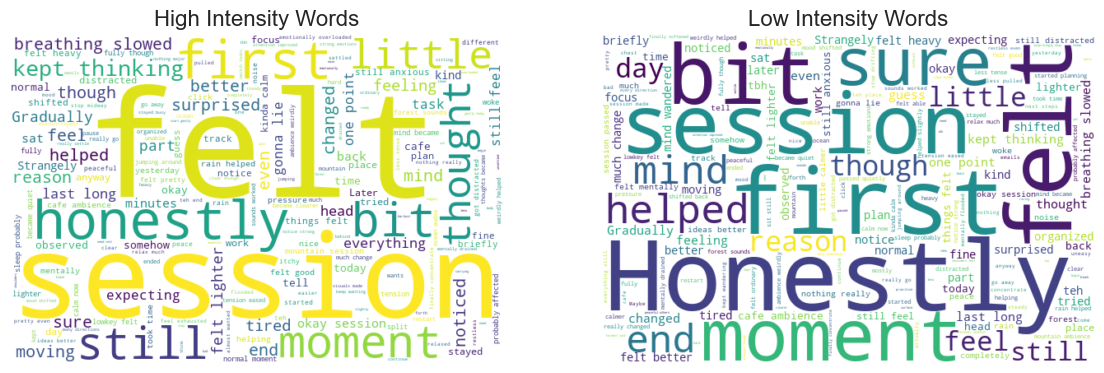

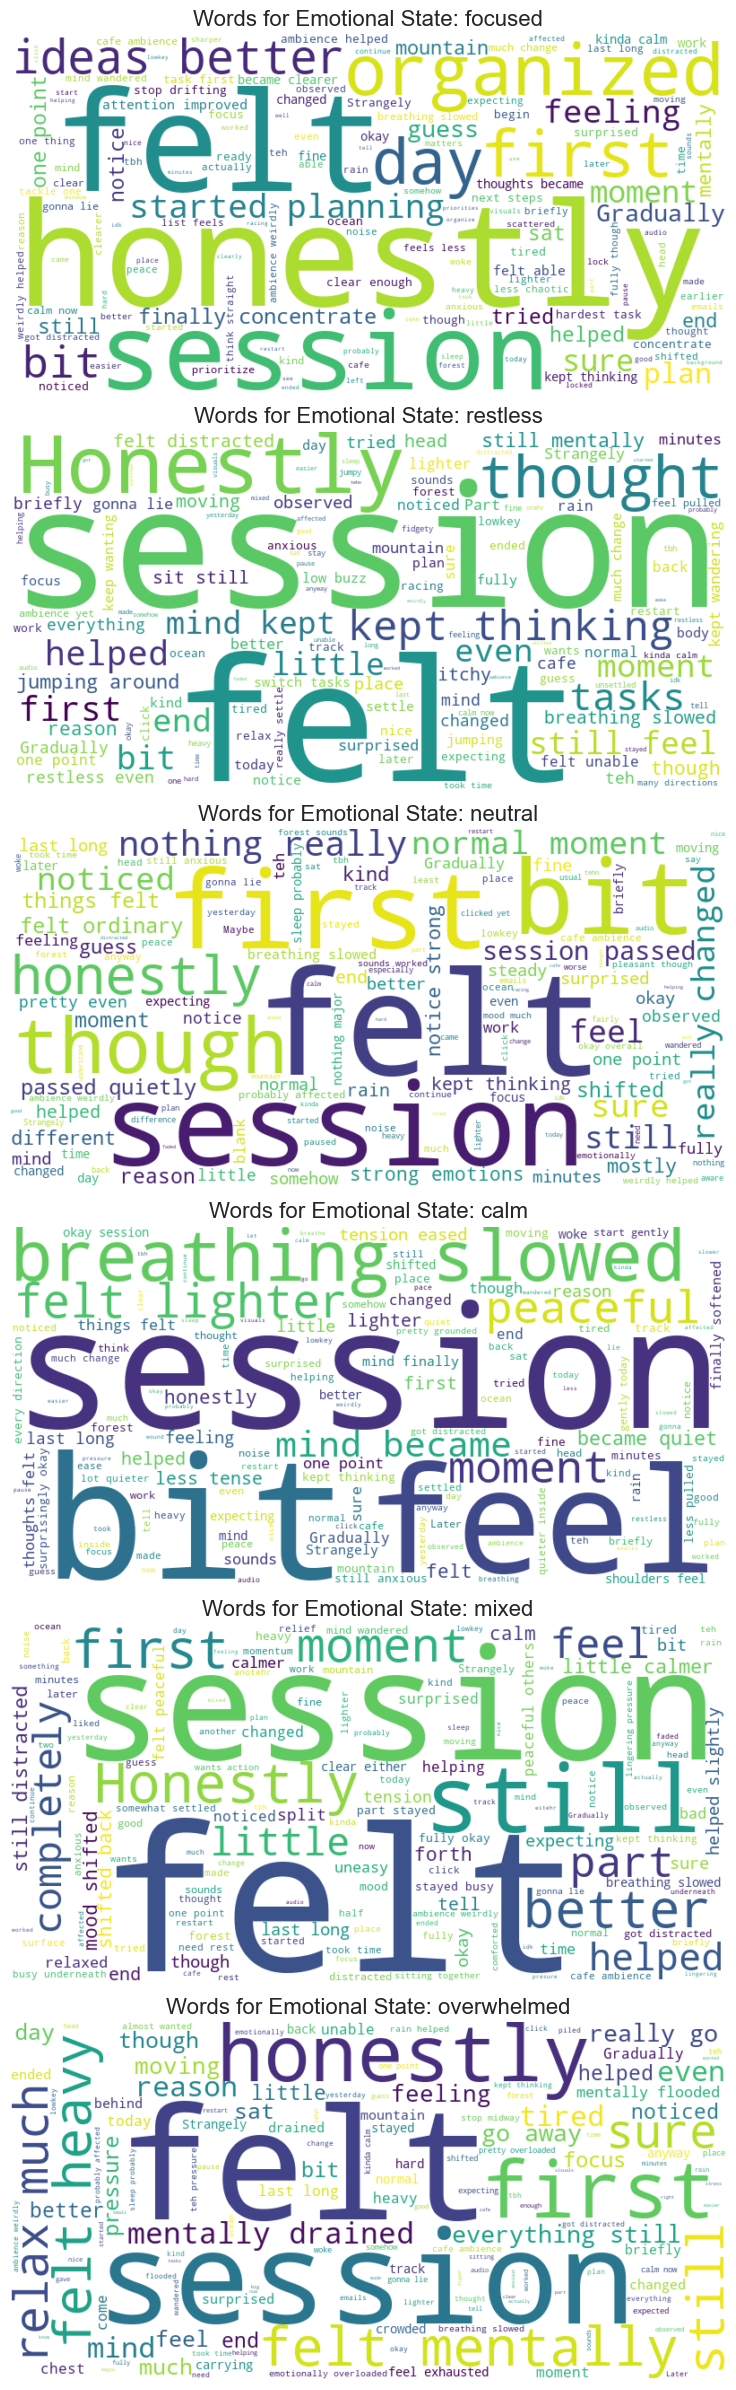

In [73]:
text_visual_report(train_df, text_column='journal_text', intensity_col='intensity', emotion_col='emotional_state')

In [74]:
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import pandas as pd

def top_words_barplots(df, text_column='journal_text', emotion_col='emotional_state', top_n=20):
    """
    Creates bar plots of top distinctive words per emotional state using TF-IDF scores.
    """
    print("🔍 Generating Top Words per Emotional State...\n")

    emotional_states = df[emotion_col].unique()

    for state in emotional_states:
        # Select text for this emotional state
        texts = df[df[emotion_col] == state][text_column]

        # TF-IDF vectorization
        tfidf = TfidfVectorizer(max_features=500, stop_words='english')
        X = tfidf.fit_transform(texts)
        feature_names = tfidf.get_feature_names_out()

        # Average TF-IDF per word
        avg_tfidf = X.mean(axis=0).A1  # convert to 1D array
        tfidf_df = pd.DataFrame({'word': feature_names, 'tfidf': avg_tfidf})
        tfidf_df = tfidf_df.sort_values('tfidf', ascending=False).head(top_n)

        # Plot
        plt.figure(figsize=(10,6))
        plt.barh(tfidf_df['word'][::-1], tfidf_df['tfidf'][::-1], color='skyblue')
        plt.xlabel('Average TF-IDF Score')
        plt.title(f'Top {top_n} Words for Emotional State: {state}')
        plt.show()

🔍 Generating Top Words per Emotional State...



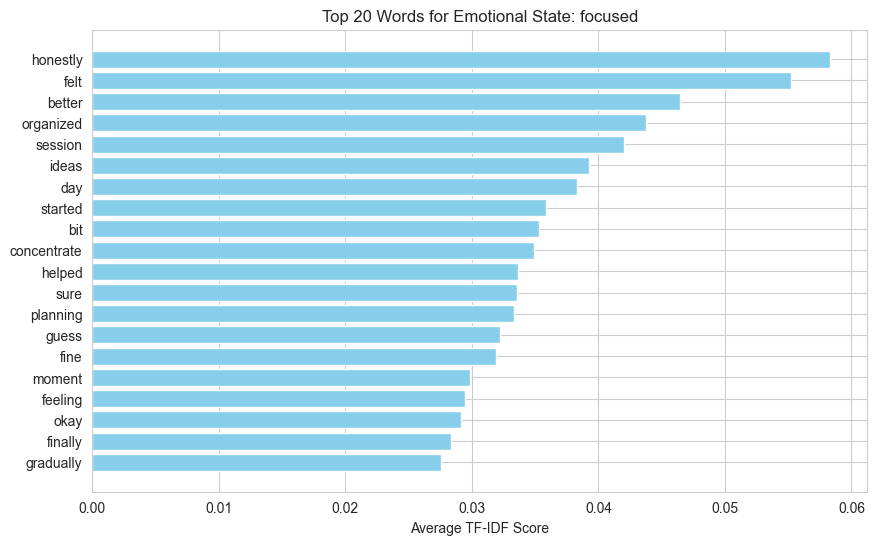

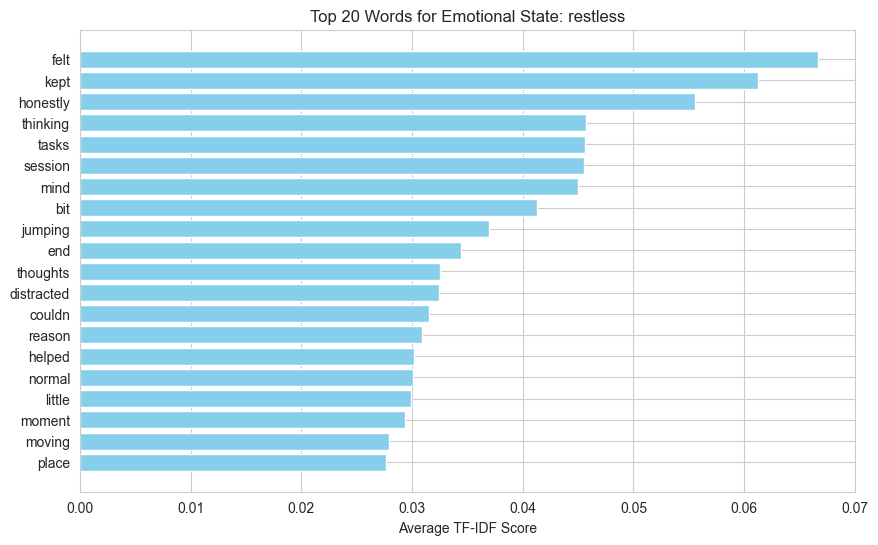

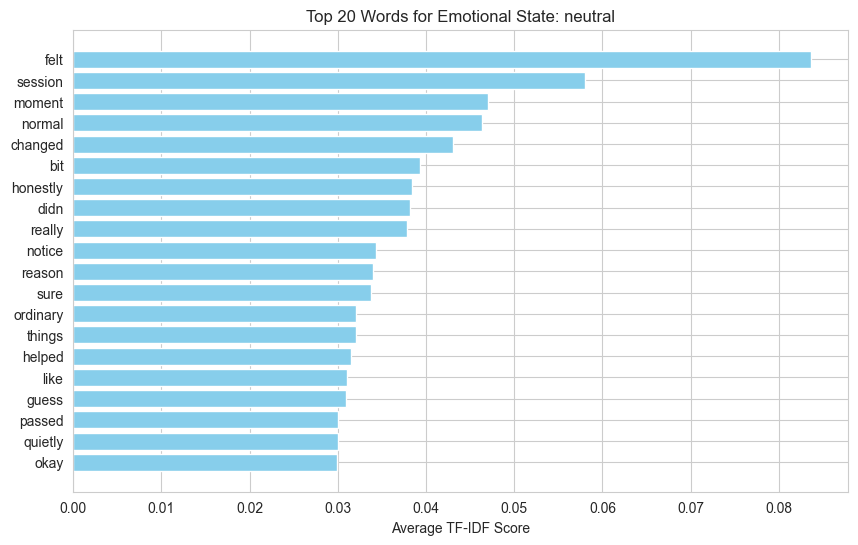

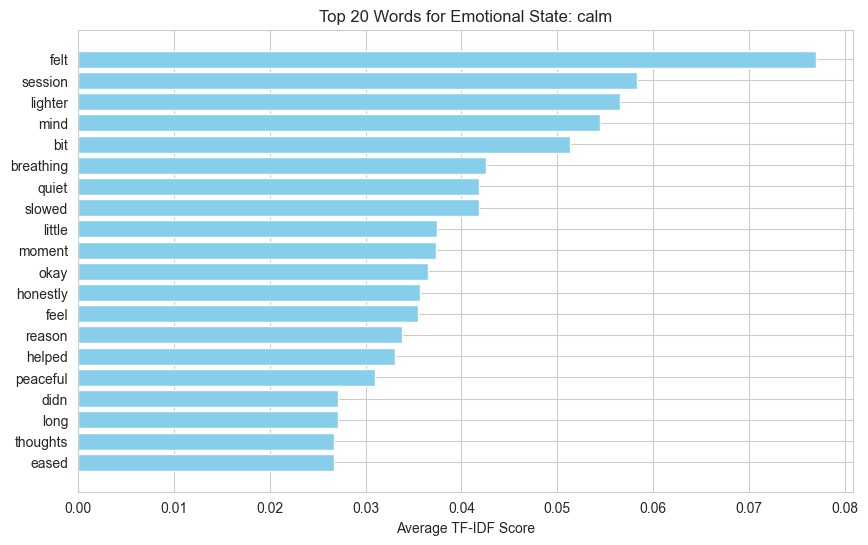

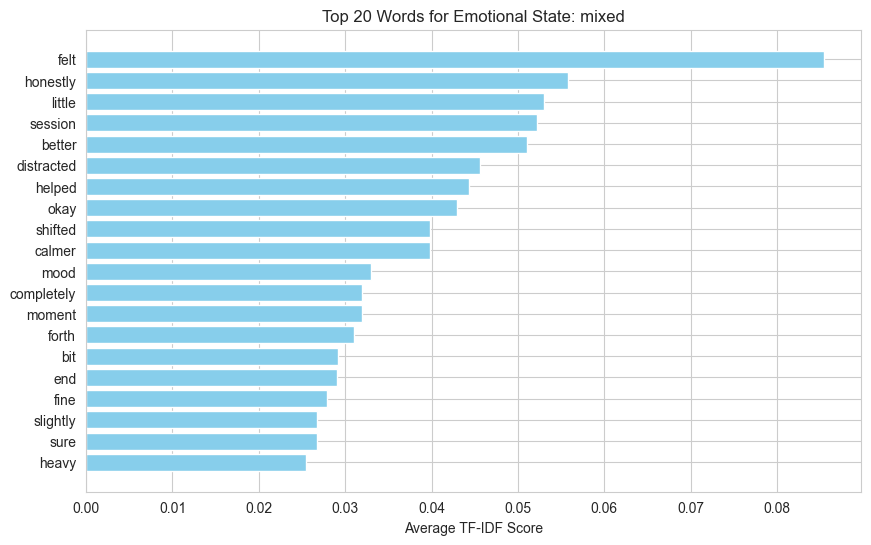

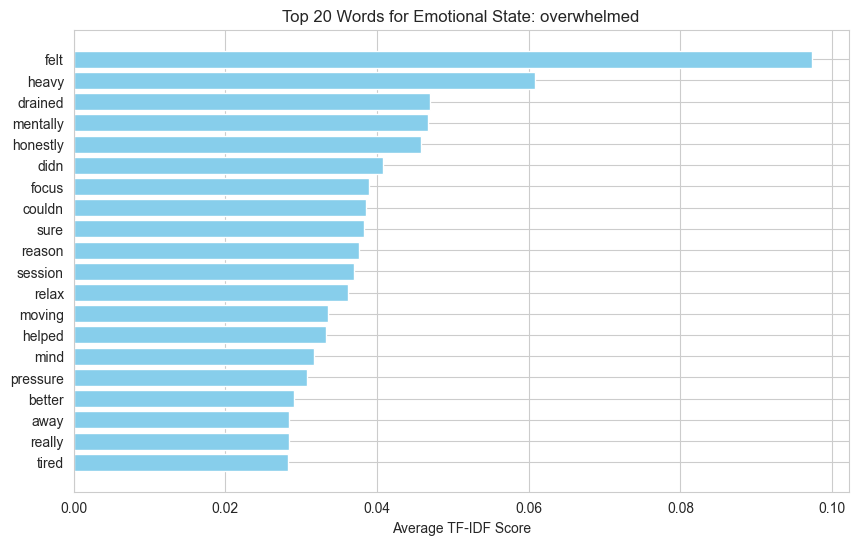

In [75]:
top_words_barplots(train_df, text_column='journal_text', emotion_col='emotional_state', top_n=20)